## POLYNOMIAL REGRESSION

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

This demonstrates polynomial regression by generating a synthetic dataset with a clear non-linear (quadratic) relationship, then comparing how simple linear regression fails to capture it versus how polynomial regression succeeds

In [2]:
X = 6 * np.random.rand(100, 1) - 3
y = 0.5 * X**2 + 1.5 * X + 2 + np.random.randn(100, 1)

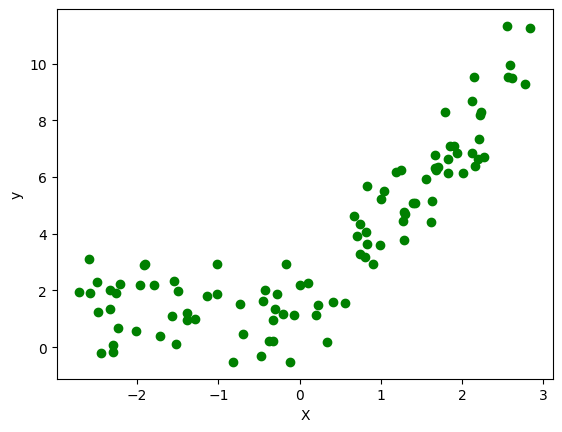

In [3]:
plt.scatter(X,y,color='green')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

the data clearly does not follow a straight-line pattern — it curves, confirming a non-linear relationship

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Evaluating with Linear Regression


In [5]:
from sklearn.linear_model import LinearRegression
regression_1 = LinearRegression()
regression_1.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [6]:
from sklearn.metrics import r2_score

y_pred = regression_1.predict(X_test)
score = r2_score(y_test, y_pred)
print(score)   # ~0.62 — noticeably poor

0.7660641658256238


0.76 is a poor score. We will also show our poor best fit line

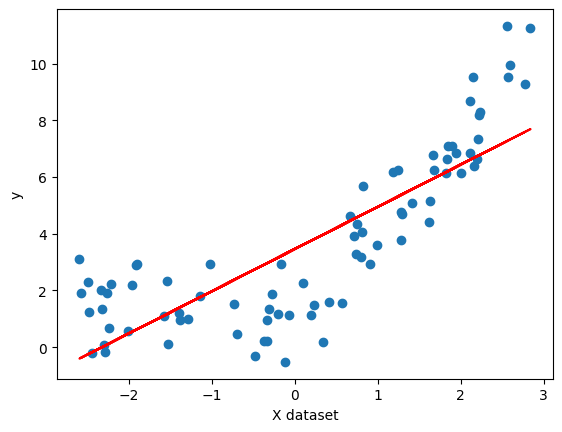

In [7]:
plt.plot(X_train, regression_1.predict(X_train), color='red')
plt.scatter(X_train, y_train)
plt.xlabel('X dataset')
plt.ylabel('y')
plt.show()

Hence we should apply polynomial regression

In [19]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2, include_bias=True)
#degree=2 tells to create x1 and x1^2. include_bias tells to add a constant column of 1s (i.e B0.x)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)
print(X_train_poly[0])

poly.fit(X_train_poly, y)
lin2 = LinearRegression()
lin2.fit(X_train_poly, y_train)

[1.         0.56458955 0.31876136]


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


- Column 1: bias (always 1)
- Column 2: x1​
- Column 3: x1^2

In [20]:
y_pred = lin2.predict(X_test_poly)
score = r2_score(y_test, y_pred)
print(score) 

0.870737687216138


This is a good score

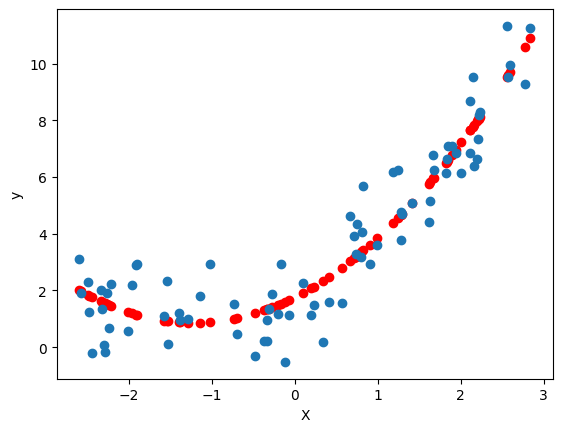

In [23]:
plt.scatter(X_train, lin2.predict(X_train_poly), color='red')
plt.scatter(X_train, y_train)
plt.xlabel('X')
plt.ylabel('y')
plt.show()

Above one was tested on degree=2. Lets test on degree=3

In [24]:
poly = PolynomialFeatures(degree=3, include_bias=True)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

lin2.fit(X_train_poly, y_train)
y_pred = lin2.predict(X_test_poly)
print(r2_score(y_test, y_pred))

0.8688430094226772


See we got a lower score hence 2 degree is better

## Predict on a new Data

In [27]:
X_new = np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lin2.predict(X_new_poly)

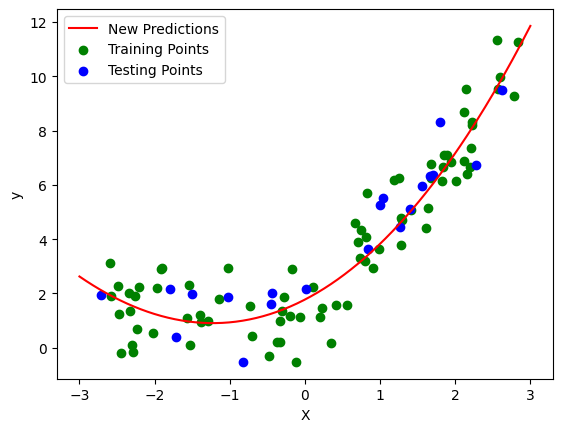

In [28]:
plt.plot(X_new, y_new, color='red', label='New Predictions')
plt.scatter(X_train, y_train, color='green', label='Training Points')
plt.scatter(X_test, y_test, color='blue', label='Testing Points')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.show()